In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit
from tensorflow.keras import layers
from tensorflow.keras.regularizers import L1L2

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

In [19]:
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

def pattern(i,z1,z2,a1,a2):
    return [int(a1*np.sin((np.pi*i)/z1)), int(a2*np.sin((np.pi*i)/z2))]

In [20]:
def build_model(L, l, r, n_class=3, kernel_size=11, NF=5, stddev=0.05):
    
    input_shape = (L, 2)

    if r == 2:
        reg = tf.keras.regularizers.l2(l)
    elif r == 1:
        reg = tf.keras.regularizers.l1(l)
    elif r == 0:
        l2 = np.abs(1-l)
        reg = L1L2(l, l2)
        
    
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=stddev, seed=None)
    
        
    model = Sequential([
        Conv1D(filters=NF, kernel_size=kernel_size,
               kernel_initializer=ini,
               kernel_regularizer=reg,
               padding='same',
               activation='relu',
               input_shape=input_shape),
        MaxPooling1D(pool_size=2), #we need to catch a signal that is above the noise
        Conv1D(filters=NF * 2, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_class, activation='softmax')
    ])
    
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=tf.keras.optimizers.Adam(),
        metrics=['accuracy']
    )
    
    return model

In [21]:


SNRs = [0.1, 0.3, 1, 3, 10, 30]

# training set size and time series
N=10000
L=60
n_class = 3
# noise bias 
bias = 5 

#duration of the pattern
d = 11 # kernel size
Z1 = Z2 = d

# since i want to test the effectiveness of SNR as a measure classifiability 
# i start by seeing if different training sets (different amplitude and time)
# but with same SNR give more or less the same result: similar accuracy after
# a fixed number of epochs
pattern_params = []
sigma = 20

for SNR in SNRs:
    SNR_partition = np.linspace(0, 1, 5)
    for s in SNR_partition:
        A_1 = (2*(np.pi + 4)*d*SNR*s / np.pi**3)**0.5 * sigma
        A_2 = (2*(np.pi + 4)*d*SNR*(1-s) / np.pi**3)**0.5 * sigma
        #mu_1, mu_2 = np.random.randint(0, 100, 2)
        for c in range(5):
            pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias, c) ) 

'''
ONLY TO GENERATE DATA

# run only to generate data
for params in pattern_params:
    y = np.zeros(N) # 1D (same label)
    x = np.zeros((N,L,2))
    Z1 = Z2 = d
    
    A1, DX1, bias1, A2, DX2, bias2, c = params 
    str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'
    print(str0)
    
    for i in range(N):
            if i>0: 
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][0][0] = x[i-1][-1][0] + jump0 
                x[i][0][1] = x[i-1][-1][1] + jump1
            
            for j in range(1,L):
                jump0, jump1 = jump(bias1, bias2, DX1, DX2)
                x[i][j][0] = x[i][j-1][0] + jump0
                x[i][j][1] = x[i][j-1][1] + jump1
                
            y[i] = i%3 
                   
            if y[i]>0:
                # 0 -> 0 0
                if y[i]<3:
                    j01, j02 = np.random.randint(0,L-1-d, 2) 
                    sign = 3-2*y[i] 
                    
                    
                    for j in range(d): 
                       p_val1, p_val2 = pattern(j, d, d, A1, A2)
        
                       x[i][j01 + j][0] += sign * p_val1 # Canale 0
                       x[i][j02 + j][1] += sign * p_val2 # Canale 1
        
                    # 1 -> + +
                    # 2 -> - -
    categ = y
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][int(categ[i])] = 1. # y contains one-hot encoding


    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)

    x_train = x_train.reshape(x_train.shape[0], L, 2)
    x_val =  x_val.reshape(x_val.shape[0], L, 2)

    fname='DATA_REG/x_ts'+str0
    np.save(fname,x_train)
    fname='DATA_REG/y_ts'+str0
    np.save(fname,y_train)
    
    fname='DATA_REG/x_vs'+str0
    np.save(fname,x_val)
    fname='DATA_REG/y_vs'+str0
    np.save(fname,y_val)
'''

"\nONLY TO GENERATE DATA\n\n# run only to generate data\nfor params in pattern_params:\n    y = np.zeros(N) # 1D (same label)\n    x = np.zeros((N,L,2))\n    Z1 = Z2 = d\n\n    A1, DX1, bias1, A2, DX2, bias2, c = params \n    str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'\n    print(str0)\n\n    for i in range(N):\n            if i>0: \n                jump0, jump1 = jump(bias1, bias2, DX1, DX2)\n                x[i][0][0] = x[i-1][-1][0] + jump0 \n                x[i][0][1] = x[i-1][-1][1] + jump1\n\n            for j in range(1,L):\n                jump0, jump1 = jump(bias1, bias2, DX1, DX2)\n                x[i][j][0] = x[i][j-1][0] + jump0\n                x[i][j][1] = x[i][j-1][1] + jump1\n\n            y[i] = i%3 \n\n            if y[i]>0:\n                # 0 -> 0 0\n                if y[i]<3:\n                    j01, j02 = np.random.randint(0,L-1-d, 2) \n                    sign = 3-2*y[i] \n\n\n                    for j in ran

In [5]:
print(len(pattern_params))

150


In [6]:
''' too much
acc = []

BATCH_SIZE = 200
EPOCHS = 10 # TO CHANGE


for params in pattern_params:
    j = 0
    A1, DX1, bias1, A2, DX2, bias2,c = params 
    str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'
    fnamex='DATA_REG/x_ts'+str0+'.npy'
    fnamey='DATA_REG/y_ts'+str0+'.npy'

    x_train = np.load(fnamex)
    y_train = np.load(fnamey)

    fxv='DATA_REG/x_vs'+str0+'.npy'
    fyv='DATA_REG/y_vs'+str0+'.npy'

    x_val = np.load(fxv)
    y_val = np.load(fyv)
    
    acc_param = []
    
    for r in range(3):
        for i in range(0, -5, -1):
            j+=1
            
            l = 0.5*10**i

            model = build_model(L, l, r, n_class=n_class)
            
            early_stop = keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=15,
                restore_best_weights=True
            )
            
            fit = model.fit(x_train, y_train,
                            batch_size=BATCH_SIZE,
                            epochs=EPOCHS,
                            validation_data=(x_val, y_val),
                            verbose=False,
                            shuffle=True,
                            callbacks=[early_stop])
            
            # Prendi il MASSIMO, non l'ultimo
            acc_param.append(max(fit.history['val_accuracy']))
                
            #print(f"Done for {params[0]}, {params[3]}, l {l}, r {r}, acc {max(fit.history['val_accuracy'])}")
            if j%20==0:
                print(j)

    acc.append(acc_param)
'''

' too much\nacc = []\n\nBATCH_SIZE = 200\nEPOCHS = 10 # TO CHANGE\n\n\nfor params in pattern_params:\n    j = 0\n    A1, DX1, bias1, A2, DX2, bias2,c = params \n    str0 = f\'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}\'\n    fnamex=\'DATA_REG/x_ts\'+str0+\'.npy\'\n    fnamey=\'DATA_REG/y_ts\'+str0+\'.npy\'\n\n    x_train = np.load(fnamex)\n    y_train = np.load(fnamey)\n\n    fxv=\'DATA_REG/x_vs\'+str0+\'.npy\'\n    fyv=\'DATA_REG/y_vs\'+str0+\'.npy\'\n\n    x_val = np.load(fxv)\n    y_val = np.load(fyv)\n\n    acc_param = []\n\n    for r in range(3):\n        for i in range(0, -5, -1):\n            j+=1\n\n            l = 0.5*10**i\n\n            model = build_model(L, l, r, n_class=n_class)\n\n            early_stop = keras.callbacks.EarlyStopping(\n                monitor=\'val_accuracy\',\n                patience=15,\n                restore_best_weights=True\n            )\n\n            fit = model.fit(x_train, y_train,\n              

In [7]:
#np.save("acc_reg.npy", acc)

In [10]:
'''
Let's see if with regularization the models trained with set with SNR = [0.1, 0.3, 1, 3, 10, 30] generalize well (as well as the SNR = 3)
on the sets with SNR = 0.1, 0.3, 1, 3, 10, 30]
'''


tr_SNR = [0.05, 0.15, 0.5, 1.5, 5, 15] # half

pat_par_train = []
models = []
acc = []

for SNR in tr_SNR:
    A_1 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    A_2 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    c = 0
    pat_par_train.append((A_1, sigma, bias, A_2, sigma, bias, c))

print(len(pat_par_train))

BATCH_SIZE = 200
EPOCHS = 250 # TO CHANGE

for params in pat_par_train:
    j = 0
    A1, DX1, bias1, A2, DX2, bias2, c = params 
    str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'
    
    fnamex='DATA_REG/x_ts'+str0+'.npy'
    fnamey='DATA_REG/y_ts'+str0+'.npy'

    x_train = np.load(fnamex)
    y_train = np.load(fnamey)

    fxv='DATA_REG/x_vs'+str0+'.npy'
    fyv='DATA_REG/y_vs'+str0+'.npy'

    x_val = np.load(fxv)
    y_val = np.load(fyv)
    
    acc_param = []
    
    for r in range(3):
        for i in range(0, -5, -1):
            j+=1
            
            l = 0.5*10**i

            model = build_model(L, l, r, n_class=n_class)
            
            early_stop = keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=15,
                restore_best_weights=True
            )
            
            fit = model.fit(x_train, y_train,
                            batch_size=BATCH_SIZE,
                            epochs=EPOCHS,
                            validation_data=(x_val, y_val),
                            verbose=False,
                            shuffle=True,
                            callbacks=[early_stop])
            
            # Prendi il MASSIMO, non l'ultimo
            acc_param.append(max(fit.history['val_accuracy']))
            models.append(model)
            print(f"Done for {params[0]}, {params[3]}, l {l}, r {r}, acc {max(fit.history['val_accuracy'])}")

    acc.append(acc_param)

6


/home/laraf/jup-env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-15 18:39:13.026764: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Done for 10.066976775827971, 10.066976775827971, l 0.5, r 0, acc 0.3449999988079071
Done for 10.066976775827971, 10.066976775827971, l 0.05, r 0, acc 0.3409999907016754
Done for 10.066976775827971, 10.066976775827971, l 0.005, r 0, acc 0.3400000035762787
Done for 10.066976775827971, 10.066976775827971, l 0.0005, r 0, acc 0.34299999475479126
Done for 10.066976775827971, 10.066976775827971, l 5e-05, r 0, acc 0.3440000116825104
Done for 10.066976775827971, 10.066976775827971, l 0.5, r 1, acc 0.34299999475479126
Done for 10.066976775827971, 10.066976775827971, l 0.05, r 1, acc 0.33799999952316284
Done for 10.066976775827971, 10.066976775827971, l 0.005, r 1, acc 0.34299999475479126
Done for 10.066976775827971, 10.066976775827971, l 0.0005, r 1, acc 0.3540000021457672
Done for 10.066976775827971, 10.066976775827971, l 5e-05, r 1, acc 0.34049999713897705
Done for 10.066976775827971, 10.066976775827971, l 0.5, r 2, acc 0.3375000059604645
Done for 10.066976775827971, 10.066976775827971, l 0.05

In [11]:
np.save("val_acc_reg_full.npy", acc)
np.save("models_full.npy", models)

In [28]:
'''
# should probably convert it into a dataframe
import pandas as pd

            pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias) )
results = []

for p in range(len(pattern_params)):
    par = pattern_params[p]
    j = 0
    for r in range(3):
        for i in range(0, -5, -1):
            j+=1
            l = 0.5*10**i
            
            accuracy = acc[p][j]
            results.append({
                    "SNR_total": params[0]**2 + params[3]**2,
                    "A1": params[0],
                    "A2": params[3],
                    "partition": params[0]**2 / (params[0]**2 + params[3]**2 + 1e-12),
                    "lambda": l,
                    "r": r,
                    "acc": accuracy)
                })

df = pd.DataFrame(results)
'''

'\n# should probably convert it into a dataframe\nimport pandas as pd\n\n            pattern_params.append( (A_1, sigma, bias, A_2, sigma, bias) )\nresults = []\n\nfor p in range(len(pattern_params)):\n    par = pattern_params[p]\n    j = 0\n    for r in range(3):\n        for i in range(0, -5, -1):\n            j+=1\n            l = 0.5*10**i\n\n            accuracy = acc[p][j]\n            results.append({\n                    "SNR_total": params[0]**2 + params[3]**2,\n                    "A1": params[0],\n                    "A2": params[3],\n                    "partition": params[0]**2 / (params[0]**2 + params[3]**2 + 1e-12),\n                    "lambda": l,\n                    "r": r,\n                    "acc": accuracy)\n                })\n\ndf = pd.DataFrame(results)\n'

In [24]:
ACC = []
test_SNR = [0.05, 0.15, 0.5, 1.5, 5, 15] # half
pat_par_test = []

models = np.load("models_full.npy", allow_pickle=True)
#acc = np.load("val_acc_reg_full.npy")

for SNR in test_SNR:
    A_1 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    A_2 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    c = 0
    pat_par_test.append((A_1, sigma, bias, A_2, sigma, bias, c))

i = 0
for m in models:
    accuracies = []

    for par in pat_par_test:
        A1, DX1, bias1, A2, DX2, bias2, c = par
        str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'
        
        fnamex='DATA_REG/x_ts'+str0+'.npy'
        fnamey='DATA_REG/y_ts'+str0+'.npy'
    
        x_train = np.load(fnamex)
        y_train = np.load(fnamey)
    
        fxv='DATA_REG/x_vs'+str0+'.npy'
        fyv='DATA_REG/y_vs'+str0+'.npy'
    
        x_val = np.load(fxv)
        y_val = np.load(fyv)

        x_test = np.concatenate((x_train, x_val))
        y_test = np.concatenate((y_train, y_val)).astype(np.int64)

        # I use x_train as test because I'm interested in testing the performance over different datasets
        # (differ
        
        loss, acc = m.evaluate(x_test, y_test, verbose=0)
        accuracies.append(acc)

    ACC.append(accuracies)
    print(i)
    i+=1
        
        
        
        

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89


In [27]:
ACC = pd.DataFrame(ACC)
np.save("ACC_full_test", ACC)
ACC

,0,1,2,3,4,5
0,0.3360,0.3365,0.3398,0.3302,0.3339,0.3109
1,0.3433,0.3337,0.3333,0.3418,0.3370,0.3245
2,0.3341,0.3389,0.3322,0.3298,0.3196,0.2871
3,0.3446,0.3410,0.3375,0.3322,0.3312,0.3139
4,0.3409,0.3382,0.3289,0.3384,0.3267,0.3400
...,...,...,...,...,...,...
85,0.3329,0.3358,0.3428,0.3902,0.7023,0.9961
86,0.3341,0.3388,0.3443,0.3909,0.7043,0.9968
87,0.3344,0.3399,0.3489,0.4030,0.7155,0.9957
88,0.3330,0.3422,0.3512,0.4074,0.7104,0.9876


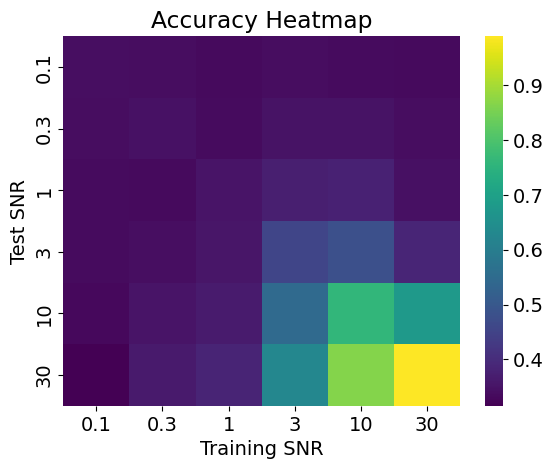

In [33]:
import pandas as pd
import seaborn as sns

tr_SNR = [0.1, 0.3, 1, 3, 10, 30]
test_SNR = [0.1, 0.3, 1, 3, 10, 30]

dict_acc = {}

# mean over different values of lambda
for i in range(3):
    dict_acc[f"reg_{i}"] = pd.concat(
        [
            ACC[(0+5*i):(5+5*i)].mean(axis=0),
            ACC[(15+5*i):(20+5*i)].mean(axis=0),
            ACC[(30+5*i):(35+5*i)].mean(axis=0),
            ACC[(45+5*i):(50+5*i)].mean(axis=0),
            ACC[(60+5*i):(65+5*i)].mean(axis=0),
            ACC[(75+5*i):(80+5*i)].mean(axis=0)
        ],
        axis=1
    )


sns.heatmap(
    dict_acc["reg_0"],
    fmt=".3f",
    cmap="viridis",
    xticklabels=tr_SNR,
    yticklabels=test_SNR
)

plt.xlabel("Training SNR")
plt.ylabel("Test SNR")
plt.title("Accuracy Heatmap")
plt.show()

In [38]:
col_means = []

for i in range(len(SNRs)):
    values = dict_acc["reg_0"][:][i]
    col_means.append(values.mean())

col_means = np.array(col_means)

print(col_means)

[0.33187    0.34472667 0.353      0.44798    0.52729    0.51090333]


In [40]:
max_idx = np.argmax(col_means)
max_val = col_means[max_idx]

print("Max col mean:", max_val)
print("corresponding SNR:", SNRs[max_idx])

Max col mean: 0.5272900005181631
corresponding SNR: 10


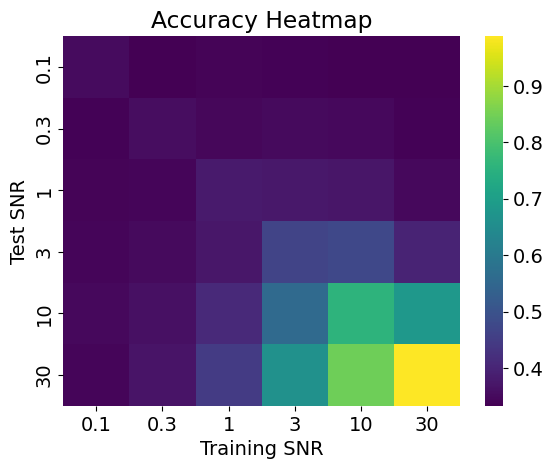

In [36]:
sns.heatmap(
    dict_acc["reg_1"],
    fmt=".3f",
    cmap="viridis",
    xticklabels=tr_SNR,
    yticklabels=test_SNR
)

plt.xlabel("Training SNR")
plt.ylabel("Test SNR")
plt.title("Accuracy Heatmap")
plt.show()

In [41]:
col_means = []

for i in range(len(SNRs)):
    values = dict_acc["reg_1"][:][i]
    col_means.append(values.mean())

col_means = np.array(col_means)

print(col_means)

[0.34267667 0.35181666 0.38132667 0.45795333 0.52129    0.51389667]


In [42]:
max_idx = np.argmax(col_means)
max_val = col_means[max_idx]

print("Max col mean:", max_val)
print("corresponding SNR:", SNRs[max_idx])

Max col mean: 0.5212900012731552
corresponding SNR: 10


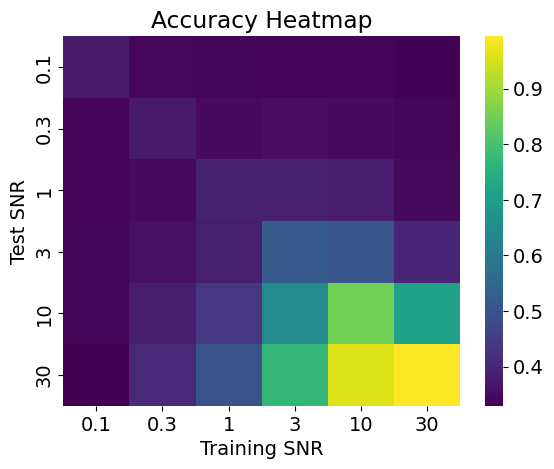

In [35]:
sns.heatmap(
    dict_acc["reg_2"],
    fmt=".3f",
    cmap="viridis",
    xticklabels=tr_SNR,
    yticklabels=test_SNR
)

plt.xlabel("Training SNR")
plt.ylabel("Test SNR")
plt.title("Accuracy Heatmap")
plt.show()

In [43]:
col_means = []

for i in range(len(SNRs)):
    values = dict_acc["reg_2"][:][i]
    col_means.append(values.mean())

col_means = np.array(col_means)

print(col_means)

[0.34255667 0.36760667 0.39953667 0.50229333 0.56466667 0.52050667]


In [44]:
max_idx = np.argmax(col_means)
max_val = col_means[max_idx]

print("Max col mean:", max_val)
print("corresponding SNR:", SNRs[max_idx])

Max col mean: 0.5646666715542475
corresponding SNR: 10


With regularization, even though results don't differ significantly, the best training SNR to generalize become 10 and we can see that probably the best type of regularization is L1L2

Now we study how accuracy varies for different values of lambda for a certain type of regularization and training on a specific SNR (it's like a zoom on a single column where now there's the mean over different values of lambda)

In [71]:
acc_reg = {}

for i in range(3):
    acc_reg[f"reg_{i}"] = pd.concat(
        [
            ACC[(0+5*i):(5+5*i)],
            ACC[(15+5*i):(20+5*i)],
            ACC[(30+5*i):(35+5*i)],
            ACC[(45+5*i):(50+5*i)],
            ACC[(60+5*i):(65+5*i)],
            ACC[(75+5*i):(80+5*i)]
        ],
        axis=0
    )

acc_lamb = {}
for i in range(3):
    for j in range(6):
        acc_lamb[(i, j)] = acc_reg[f"reg_{i}"].iloc[5*j : 5*(j+1)]
        

In [72]:
acc_reg["reg_1"]

,0,1,2,3,4,5
5,0.3400,0.3423,0.3402,0.3519,0.3708,0.4091
6,0.3344,0.3301,0.3298,0.3278,0.3189,0.2818
7,0.3452,0.3372,0.3343,0.3336,0.3385,0.3204
8,0.3824,0.3416,0.3496,0.3510,0.3718,0.3854
9,0.3572,0.3352,0.3383,0.3438,0.3294,0.3083
20,0.3311,0.3354,0.3375,0.3306,0.3343,0.3363
21,0.3349,0.3472,0.3395,0.3415,0.3432,0.3315
22,0.3349,0.3437,0.3343,0.3515,0.3525,0.3544
23,0.3394,0.3807,0.3469,0.3685,0.3913,0.4080
24,0.3346,0.3728,0.3486,0.3594,0.3843,0.4057


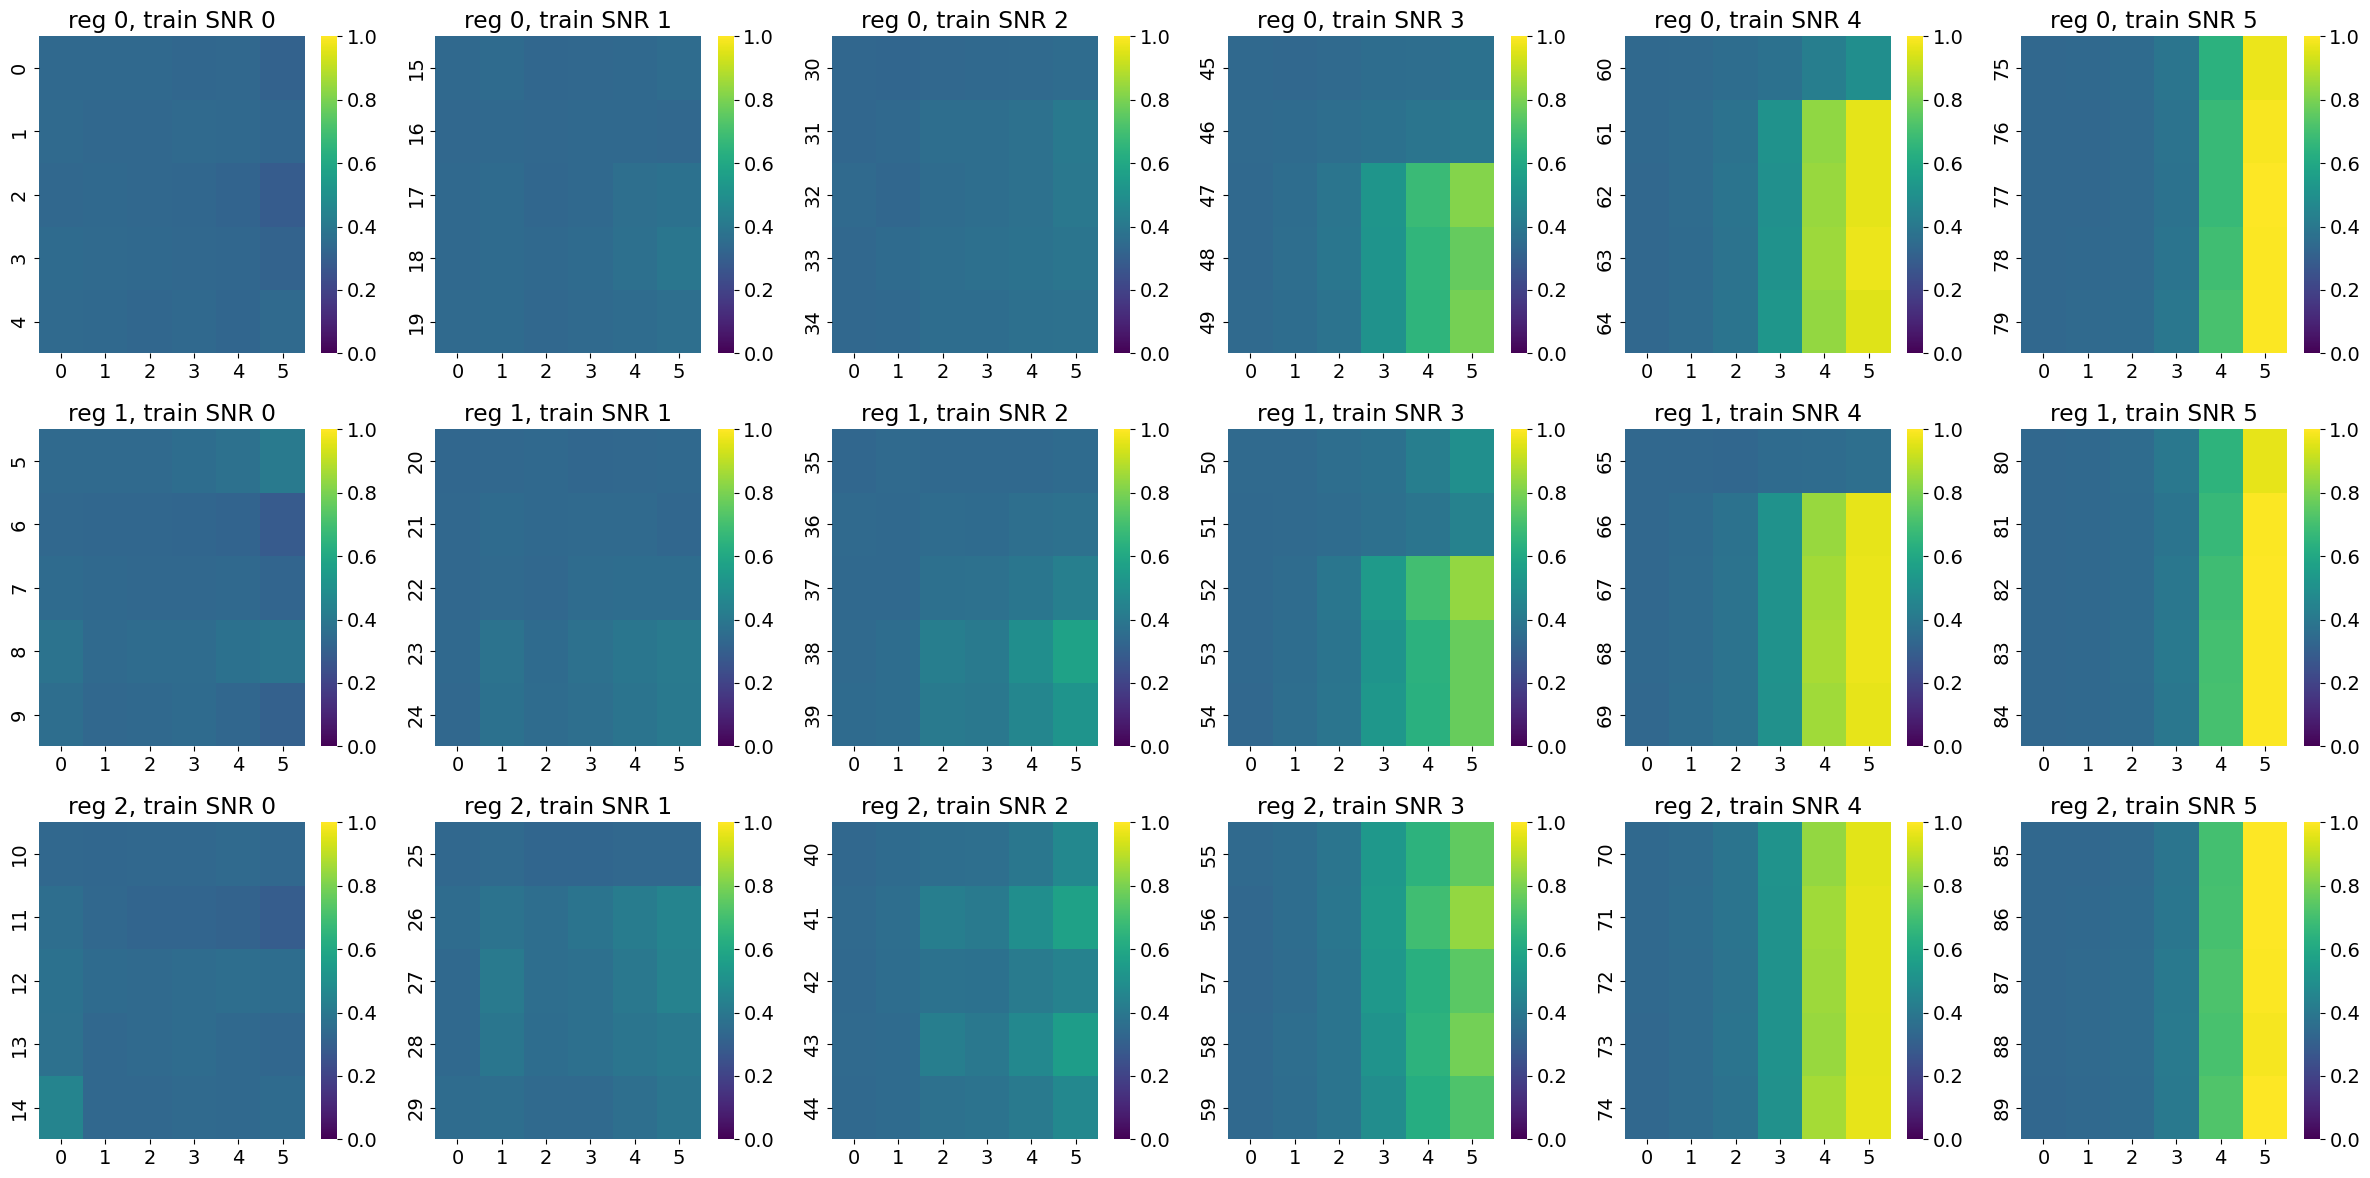

In [75]:
fig, axes = plt.subplots(3, 6, figsize=(24, 12))

for i in range(3):
    for j in range(6):

        sns.heatmap(
            acc_lamb[(i,j)],
            annot=False,
            fmt=".2f",
            cmap="viridis",
            vmin=0,
            vmax=1,
            cbar=True,
            ax=axes[i,j]
        )

        axes[i,j].set_title(f"reg {i}, train SNR {j}")

plt.tight_layout()
plt.show()